In [1]:
import gudhi, persim, tadasets
from ripser import ripser
from scipy.spatial import Delaunay
import numpy as np, matplotlib.pyplot as plt
print("Stage 2 ready")

Stage 2 ready


plan:
generate noisy circle
compute VR (Ripser) and Alpha(GUDHI)
compute Delaunay Triangulation (scipy.spatial) to see underlying Alpha complex
use persim for diagram comparison (Wasserstein/Bottleneck distance)
compare persistence diagrams
create comparison table
draw conclusions

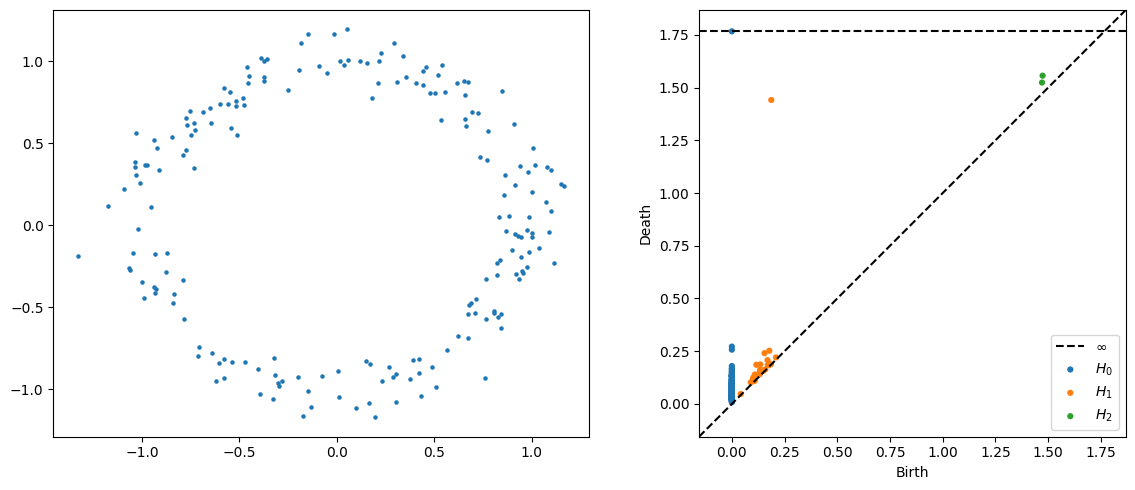

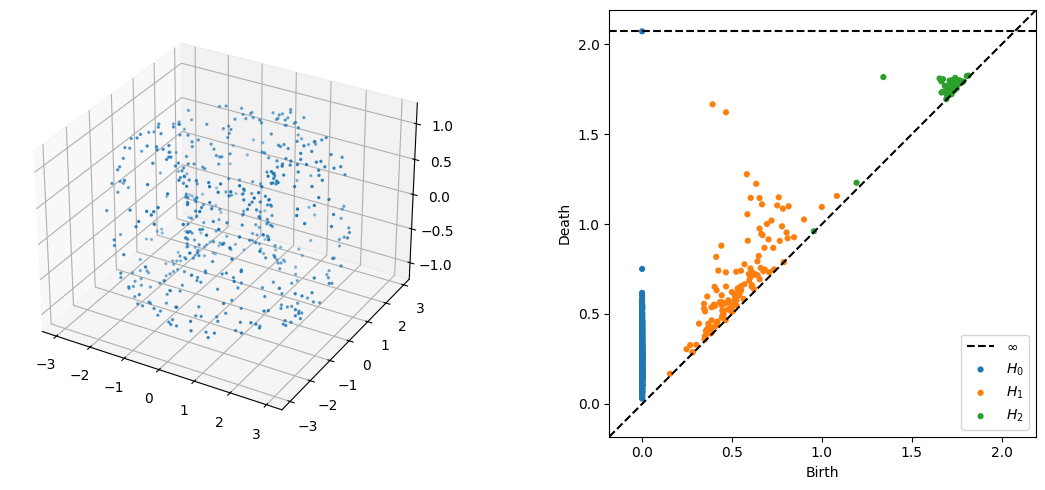

In [2]:
circle_pts = tadasets.dsphere(n=200, d=1, r=1, noise=0.1)  # d=1 → 1-sphere = circle
torus_pts  = tadasets.torus(n=500, c=2, a=1, noise=0.05)   # c=major radius, a=minor radius

datasets = (circle_pts, torus_pts)

from persim import plot_diagrams

import matplotlib.pyplot as plt

for pts in datasets:
    # Plot point cloud
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    if pts.shape[1] == 2:
        axes[0].scatter(pts[:, 0], pts[:, 1], s=5)
    else:  # 3D torus
        ax3d = fig.add_subplot(121, projection='3d')
        axes[0].remove()
        ax3d.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=2)
    
    # Persistence diagram
    plt.sca(axes[1])
    dgms_rips = ripser(pts, maxdim=2)['dgms']
    plot_diagrams(dgms_rips, show=False, ax=axes[1])
    
    plt.tight_layout()
    plt.show()